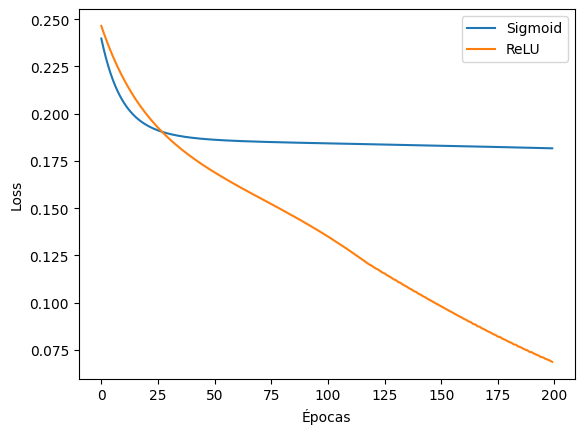

Loss final Sigmoid: 0.18167690305344292
Loss final ReLU: 0.06859300816320359
Accuracy Sigmoid: 0.75
Accuracy ReLU: 1.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Dataset OR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[1]])

# Activaciones
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

# Derivadas
def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

def relu_derivative(z):
    return (z > 0).astype(float)

# Red neuronal básica
class SimpleNN:
    def __init__(self, activation="sigmoid", lr=0.1, epochs=200):
        self.lr = lr
        self.epochs = epochs
        self.activation = activation

        # Pesos iniciales
        self.W1 = np.random.randn(2,4) * 0.1
        self.b1 = np.zeros((1,4))
        self.W2 = np.random.randn(4,1) * 0.1
        self.b2 = np.zeros((1,1))

    def act(self, z):
        return sigmoid(z) if self.activation=="sigmoid" else relu(z)

    def act_derivative(self, z):
        return sigmoid_derivative(z) if self.activation=="sigmoid" else relu_derivative(z)

    def train(self, X, y):
        losses = []
        for epoch in range(self.epochs):
            # Forward
            z1 = X @ self.W1 + self.b1
            a1 = self.act(z1)
            z2 = a1 @ self.W2 + self.b2
            a2 = sigmoid(z2)  # salida entre 0 y 1

            # Loss (MSE)
            loss = np.mean((y - a2)**2)
            losses.append(loss)

            # Backpropagation
            dz2 = (a2 - y) * sigmoid_derivative(z2)
            dW2 = a1.T @ dz2
            db2 = np.sum(dz2, axis=0, keepdims=True)

            dz1 = dz2 @ self.W2.T * self.act_derivative(z1)
            dW1 = X.T @ dz1
            db1 = np.sum(dz1, axis=0, keepdims=True)

            # Actualización
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

        return losses, a2


# Red con Sigmoid
nn_sigmoid = SimpleNN(activation="sigmoid", lr=0.1, epochs=200)
losses_sigmoid, out_sigmoid = nn_sigmoid.train(X, y)

# Red con ReLU
nn_relu = SimpleNN(activation="relu", lr=0.1, epochs=200)
losses_relu, out_relu = nn_relu.train(X, y)


# Gráfico de pérdidas
plt.plot(losses_sigmoid, label="Sigmoid")
plt.plot(losses_relu, label="ReLU")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Después de entrenar
print("Loss final Sigmoid:", losses_sigmoid[-1])
print("Loss final ReLU:", losses_relu[-1])
# Métricas
print("Accuracy Sigmoid:", accuracy_score(y, (out_sigmoid>0.5).astype(int)))
print("Accuracy ReLU:", accuracy_score(y, (out_relu>0.5).astype(int)))

## Conclusiones

 **Diferencias entre activaciones**  
- La red con ReLU logró un mejor desempeño final que la red con Sigmoid.  
- ReLU alcanzó una accuracy perfecta, mientras que Sigmoid se quedó en un nivel más bajo.  
- Esto muestra que la elección de la función de activación influye directamente en los resultados.

### Comportamiento del entrenamiento


 **Comportamiento del loss y la métrica**  
- El loss con ReLU disminuyó de manera más rápida y estable, llegando a un valor más bajo.  
- Con Sigmoid, el loss también bajó, pero se estabilizó en un nivel más alto y el aprendizaje fue más lento.  
- La métrica de accuracy refleja esta diferencia: ReLU alcanzó el máximo más rápido y con mayor consistencia.



 **Hallazgos y dificultades**  
- La función Sigmoid puede presentar saturación, lo que limita la actualización de los parámetros y ralentiza el aprendizaje.  
- ReLU evita la saturación en la mayoría de los casos, lo que facilita una convergencia más eficiente.  
- En problemas simples como el OR, ambas activaciones funcionan, pero ReLU ofrece ventajas claras en velocidad y precisión.  
- Un posible riesgo de ReLU es la aparición de “neuronas muertas”, aunque en este caso no afectó el resultado.
